In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Problem statement
In 2023 Pfizer acquired Seagen for `$43` billion, financing the deal with roughly `$31B` in long-term debt plus `$8B` in commercial paper and staking the return on Seagen's antibody-drug conjugate (ADC) franchise reaching $10B in risk-adjusted revenue by 2030. That thesis is exposed on several fronts at once: a stretched balance sheet, IRA Medicare drug-price negotiation, FDA approval timing, patent cliffs and biosimilar entry, retention of scarce ADC scientific talent, and the integration of a 3,400-person biotech into an 80,000-person enterprise. This risk assessment identifies, categorizes, and scores those exposures so that the highest-severity risks — the ones most likely to derail the deal economics — can be prioritized for monitoring and mitigation rather than treated as a single headline number.

In [2]:
# Load the risk register directly from Google Drive
# (the file's sharing must be set to "Anyone with the link")
file_id = "1g0teLbHuWSV9YBP8Oj6My0FD0MuWbPzJ"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df_risk_register = pd.read_csv(url)

# Preview the first few rows
df_risk_register.head()


,Risk #,The Risk of/That,Likelihood Score,Impact Score
0,1,Interest coverage ratio falling below safe levels,7,9
1,2,Failure to achieve $10B Seagen 2030 revenue ta...,7,9
2,3,IRA Medicare drug-price negotiations compress ...,8,8
3,4,FDA Complete Response Letter (CRL) or labellin...,6,7
4,5,Patent cliff and ADCETRIS biosimilar entry risk,6,8


In [3]:
# Select and rename relevant columns
risk_df = df_risk_register[['Risk #', 'The Risk of/That', 'Likelihood Score', 'Impact Score']].dropna()
risk_df.columns = ['Risk_ID', 'Risk_Description', 'Likelihood_Score', 'Impact_Score']

# Define severity label based on likelihood and impact scores
def classify_severity(row):
    if row['Likelihood_Score'] >= 8 and row['Impact_Score'] >= 5:
        return 'High'
    elif row['Likelihood_Score'] >= 5 or row['Impact_Score'] >= 3:
        return 'Medium'
    else:
        return 'Low'

# Apply function to classify severity
risk_df['Severity_Label'] = risk_df.apply(classify_severity, axis=1)

# View cleaned data
risk_df.head()


,Risk_ID,Risk_Description,Likelihood_Score,Impact_Score,Severity_Label
0,1,Interest coverage ratio falling below safe levels,7,9,Medium
1,2,Failure to achieve $10B Seagen 2030 revenue ta...,7,9,Medium
2,3,IRA Medicare drug-price negotiations compress ...,8,8,High
3,4,FDA Complete Response Letter (CRL) or labellin...,6,7,Medium
4,5,Patent cliff and ADCETRIS biosimilar entry risk,6,8,Medium


In [4]:
from sklearn.ensemble import RandomForestClassifier

# This model uses a Random Forest classifier with 100 decision trees to predict risk severity levels based on likelihood and impact scores.
# Define the model
model = RandomForestClassifier(n_estimators=100, random_state=42)


In [5]:
# Re-select features and target : defines the feature matrix (X) using Likelihood and Impact scores,
# and create the target variable (y) by assigning severity labels (Low, Medium, High) based on a rule-based thresholding logic applied to each risk.
X = df_risk_register[['Likelihood Score', 'Impact Score']]
y = df_risk_register.apply(
    lambda row: 'High' if row['Likelihood Score'] >= 8 and row['Impact Score'] >= 5
    else 'Medium' if row['Likelihood Score'] >= 5 or row['Impact Score'] >= 3
    else 'Low',
    axis=1
)


In [6]:
from sklearn.model_selection import cross_val_score

# Evaluate the Random Forest model using 5-fold cross-validation, which is preferred over a single train-test split due to the small size of the dataset.
# Report the mean accuracy across folds and individual fold scores to assess how well the model generalizes to unseen risk classification scenarios.

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"Mean accuracy (5-fold CV): {scores.mean():.2f}")
print("Accuracy for each fold:", scores)


Mean accuracy (5-fold CV): 0.95
Accuracy for each fold: [0.75 1.   1.   1.   1.  ]


### Note:
Across the 16 risks in this register the rule-based labels collapse into just two classes — 14 *Medium* and 2 *High*, with no *Low* — so the high cross-validated accuracy mostly reflects the model defaulting to the dominant *Medium* class. With only two *High* examples, this result should be interpreted with caution. Adding more labeled risks (for example, pooling with the wider Group 10 register) or using stratified sampling would improve evaluation reliability.

In [7]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Cross-validated predictions
y_pred_cv = cross_val_predict(model, X, y, cv=5)

# Classification metrics
print("Classification Report:")
print(classification_report(y, y_pred_cv))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y, y_pred_cv))


Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.50      0.67         2
      Medium       0.93      1.00      0.97        14

    accuracy                           0.94        16
   macro avg       0.97      0.75      0.82        16
weighted avg       0.94      0.94      0.93        16

Confusion Matrix:
[[ 1  1]
 [ 0 14]]


The model classifies the majority *Medium* risks almost perfectly but recovers only one of the two *High* risks, misclassifying the other as *Medium* — the expected behavior when a class has very few examples.

Recommendation: expand the register (or pool it with the wider Group 10 risk set) and apply stratified sampling so that *High* and any *Low* risks are represented well enough to classify fairly.

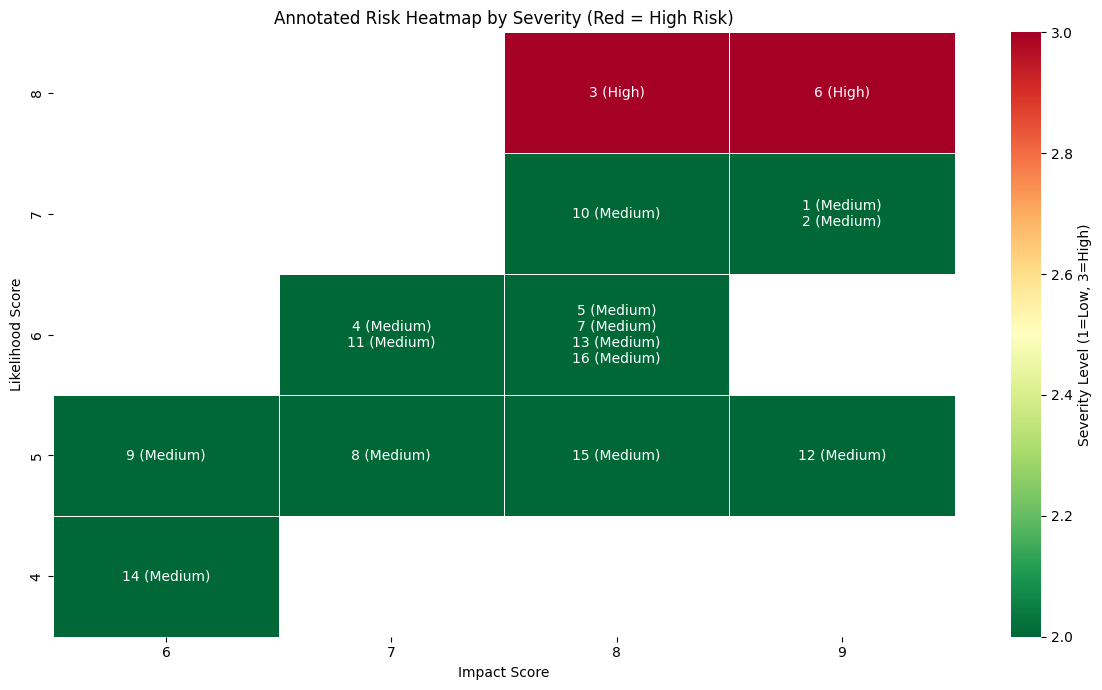

In [8]:
severity_map = df_risk_register.copy()

# Define severity classification logic
def classify_severity(row):
    if row['Likelihood Score'] >= 8 and row['Impact Score'] >= 5:
        return 'High'
    elif row['Likelihood Score'] >= 5 or row['Impact Score'] >= 3:
        return 'Medium'
    else:
        return 'Low'

# Apply classification and map severity to numeric scale
severity_map['Severity'] = severity_map.apply(classify_severity, axis=1)
severity_levels = {'Low': 1, 'Medium': 2, 'High': 3}
severity_map['Severity_Num'] = severity_map['Severity'].map(severity_levels)

# Create Risk ID label (Risk # already carries the 'R-0xx' prefix)
severity_map['Label'] = severity_map['Risk #'].astype(str) + ' (' + severity_map['Severity'] + ')'

# Pivot table with most severe risk per cell
pivot_severity = severity_map.groupby(['Likelihood Score', 'Impact Score'])['Severity_Num'].max().unstack()
pivot_severity = pivot_severity.sort_index(ascending=False)
pivot_severity = pivot_severity[pivot_severity.columns.sort_values()]

# Annotation matrix (Risk IDs and severity)
label_matrix = severity_map.groupby(['Likelihood Score', 'Impact Score'])['Label'] \
                           .apply(lambda x: '\n'.join(x)).unstack(fill_value='')
label_matrix = label_matrix.sort_index(ascending=False)
label_matrix = label_matrix[label_matrix.columns.sort_values()]

# Plot severity heatmap with annotations
plt.figure(figsize=(12, 7))
sns.heatmap(pivot_severity, annot=label_matrix, fmt='', cmap='RdYlGn_r', linewidths=0.5,
            cbar_kws={'label': 'Severity Level (1=Low, 3=High)'})
plt.title("Annotated Risk Heatmap by Severity (Red = High Risk)")
plt.xlabel("Impact Score")
plt.ylabel("Likelihood Score")
plt.tight_layout()
plt.show()


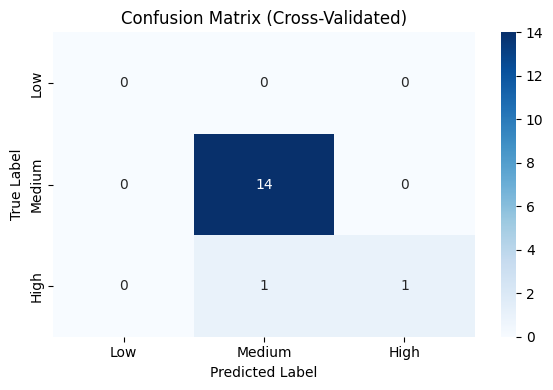

In [9]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

# Reuse model and labels
y_pred_cv = cross_val_predict(model, X, y, cv=5)
conf_matrix = confusion_matrix(y, y_pred_cv, labels=['Low', 'Medium', 'High'])

# Plot confusion matrix as heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title("Confusion Matrix (Cross-Validated)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


### Interpretation
The heatmap places each risk on the likelihood x impact grid and colors it by rule-based severity (red = High). The two High-severity cells are **R-003** (IRA price compression, L8 x I8) and **R-006** (ADC talent attrition, L8 x I9) — both clearing the "Likelihood >= 8 and Impact >= 5" rule. Note that this rule-based severity is stricter than the analyst-assigned **Priority** column in the register (which also flags R-001, R-002, and R-010 as High and R-006 as Critical); the model is deliberately learning the L x I rule, not the Priority field.

We are using a Random Forest classifier to predict one of three severity categories: Low, Medium, and High.

### Confusion Matrix Breakdown

14 out of 14 Medium risks were correctly predicted: very strong performance on the majority class.

1 of the 2 High risks was correctly predicted, but the other was misclassified as Medium.

No Low class exists in this register, so that row and column are empty — every risk in a deal of this scale clears the Medium threshold.

This is the same small-data, class-imbalance pattern the reference notebook flags: reliable on the dominant class, shaky on the rare one.